# Quantum Entanglement Swapping - 3 Qubit Simulation
**Separated into 4 individual figures:**
  - Fig 1 - Circuit Diagram
  - Fig 2 - Entanglement Entropy + Measurement Histogram
  - Fig 3 - Statevector Probability (all 4 layers)
  - Fig 4 - Bloch Spheres (4 layers x 3 qubits)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, entropy, DensityMatrix, SparsePauliOp
from qiskit_aer import AerSimulator

## Config

NUM_QUBITS = 3
layers = [
    [("h",  [0])],
    [("cx", [0, 1])],
    [("cx", [1, 2]), ("h", [1])],
    [("cx", [1, 2]), ("cz", [0, 2])],
]

In [20]:
NUM_QUBITS = 3
layers = [
    [("h",  [0])],
    [("cx", [0, 1])],
    [("cx", [1, 2]), ("h", [1])],
    [("cx", [1, 2]), ("cz", [0, 2])],
]

LAYER_LABELS = [
    "Layer 1 - H(q0)",
    "Layer 2 - CNOT q0->q1  [Bell pair]",
    "Layer 3 - CNOT q1->q2 + H(q1)  [BSM]",
    "Layer 4 - CNOT q1->q2 + CZ q0,q2  [Corrections]",
]

In [21]:
LAYER_SHORT = ["L1\nH(q0)", "L2\nCNOT q0->q1", "L3\nBSM on q1", "L4\nCorrections"]
QUBIT_COLORS = ["#1f77b4", "#d62728", "#2ca02c"]
COLORS4      = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]
LAYER_BG     = ["#dbeafe", "#fef9c3", "#dcfce7", "#ffe4e6"]

In [22]:
def rc_white():
    plt.rcParams.update({
        "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": "black",   "axes.labelcolor": "black",
        "xtick.color": "black",      "ytick.color": "black",
        "text.color": "black",       "legend.facecolor": "white",
        "legend.edgecolor": "black",
    })

In [23]:
def build_circuit_up_to(layer_idx):
    qc = QuantumCircuit(NUM_QUBITS)
    for li in range(layer_idx + 1):
        for gate, qargs in layers[li]:
            if gate == "h":    qc.h(qargs[0])
            elif gate == "cx": qc.cx(qargs[0], qargs[1])
            elif gate == "cz": qc.cz(qargs[0], qargs[1])
        if li < layer_idx:
            qc.barrier()
    return qc

In [24]:
def bloch_coords(sv, qubit, n):
    def make_op(p):
        ops = ["I"] * n; ops[qubit] = p
        return SparsePauliOp("".join(reversed(ops)))
    x = float(sv.expectation_value(make_op("X")).real)
    y = float(sv.expectation_value(make_op("Y")).real)
    z = float(sv.expectation_value(make_op("Z")).real)
    return x, y, z

## COMPUTE ALL DATA

In [25]:
print("=" * 65)
print("  ENTANGLEMENT SWAPPING -- Step-by-step Debug")
print("=" * 65)

statevectors = []
entanglement_entropy_q02 = []
bloch_data = {}

for li in range(4):
    qc = build_circuit_up_to(li)
    sv = Statevector.from_instruction(qc)
    statevectors.append(sv)

    dm_full = DensityMatrix(sv)
    rho_02  = partial_trace(dm_full, [1])
    rho_0   = partial_trace(rho_02,  [1])
    ee = entropy(rho_0, base=2)
    entanglement_entropy_q02.append(float(ee.real))

    for q in range(NUM_QUBITS):
        bloch_data[(li, q)] = bloch_coords(sv, q, NUM_QUBITS)

    print(f"\n{'─'*65}")
    print(f"  {LAYER_LABELS[li]}")
    print(f"{'─'*65}")
    print(f"  Gates: {layers[li]}")
    print(f"  Statevector |psi> (|amp|>0.01):")
    basis = [f"|{i:03b}>" for i in range(8)]
    for idx, amp in enumerate(sv.data):
        if abs(amp) > 0.01:
            print(f"    {basis[idx]}  {amp.real:+.4f}{amp.imag:+.4f}i  p={abs(amp)**2:.4f}")
    print(f"  Bloch coords:")
    for q in range(3):
        bx, by, bz = bloch_data[(li, q)]
        r  = np.sqrt(bx**2 + by**2 + bz**2)
        th = np.degrees(np.arccos(np.clip(bz/r, -1, 1))) if r > 1e-6 else 0.0
        ph = np.degrees(np.arctan2(by, bx))
        print(f"    q{q}: x={bx:+.4f} y={by:+.4f} z={bz:+.4f}  |r|={r:.4f}  theta={th:.1f} phi={ph:.1f}")
    print(f"  Entanglement Entropy S(q0) in {{q0,q2}} = {ee.real:.4f} ebits")
    status = "[ENTANGLED]" if ee.real > 0.9 else ("[PARTIAL]" if ee.real > 0.01 else "[NOT entangled]")
    print(f"  {status}")

print(f"\n{'='*65}")
print(f"  VERDICT: S(q0) after Layer 4 = {entanglement_entropy_q02[-1]:.4f} ebits")
if entanglement_entropy_q02[-1] > 0.9:
    print("  YES -- q0 and q2 are maximally entangled! (Entanglement Swapping confirmed)")
print(f"{'='*65}\n")

  ENTANGLEMENT SWAPPING -- Step-by-step Debug

─────────────────────────────────────────────────────────────────
  Layer 1 - H(q0)
─────────────────────────────────────────────────────────────────
  Gates: [('h', [0])]
  Statevector |psi> (|amp|>0.01):
    |000>  +0.7071+0.0000i  p=0.5000
    |001>  +0.7071+0.0000i  p=0.5000
  Bloch coords:
    q0: x=+1.0000 y=+0.0000 z=+0.0000  |r|=1.0000  theta=90.0 phi=0.0
    q1: x=+0.0000 y=+0.0000 z=+1.0000  |r|=1.0000  theta=0.0 phi=0.0
    q2: x=+0.0000 y=+0.0000 z=+1.0000  |r|=1.0000  theta=0.0 phi=0.0
  Entanglement Entropy S(q0) in {q0,q2} = 0.0000 ebits
  [NOT entangled]

─────────────────────────────────────────────────────────────────
  Layer 2 - CNOT q0->q1  [Bell pair]
─────────────────────────────────────────────────────────────────
  Gates: [('cx', [0, 1])]
  Statevector |psi> (|amp|>0.01):
    |000>  +0.7071+0.0000i  p=0.5000
    |011>  +0.7071+0.0000i  p=0.5000
  Bloch coords:
    q0: x=+0.0000 y=+0.0000 z=+0.0000  |r|=0.0000  theta

In [26]:
qc_meas = build_circuit_up_to(3)
qc_meas.measure_all()
simulator = AerSimulator()
counts = simulator.run(qc_meas, shots=4096).result().get_counts()
print("Aer measurement results (4096 shots):")
for s, c in sorted(counts.items(), key=lambda x: -x[1])[:8]:
    print(f"  |{s}>  {c:4d}  {'#'*int(c/40)}")

Aer measurement results (4096 shots):
  |011>  1080  ###########################
  |000>  1026  #########################
  |101>  1012  #########################
  |110>   978  ########################


## FIGURE 1 — Circuit Diagram

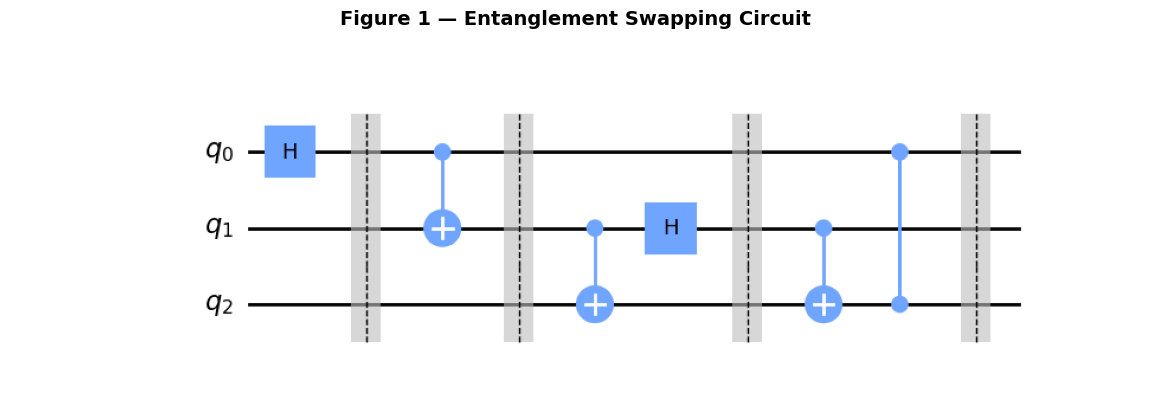

In [27]:
rc_white()
fig1, ax1 = plt.subplots(figsize=(14, 4), facecolor="white")
ax1.axis("off")
fig1.suptitle("Figure 1 — Entanglement Swapping Circuit", fontsize=14, fontweight="bold")

qc_draw = build_circuit_up_to(3)
qc_draw.barrier()
cf = qc_draw.draw("mpl", style="clifford", fold=-1)
cf.set_facecolor("white")
cf.canvas.draw()
buf = np.frombuffer(cf.canvas.tostring_argb(), dtype=np.uint8)
w, h = cf.canvas.get_width_height()
img = buf.reshape(h, w, 4)[:, :, 1:]
ax1.imshow(img)
plt.close(cf)
plt.tight_layout()
plt.show()

## FIGURE 2 — Entanglement Entropy + Measurement Histogram

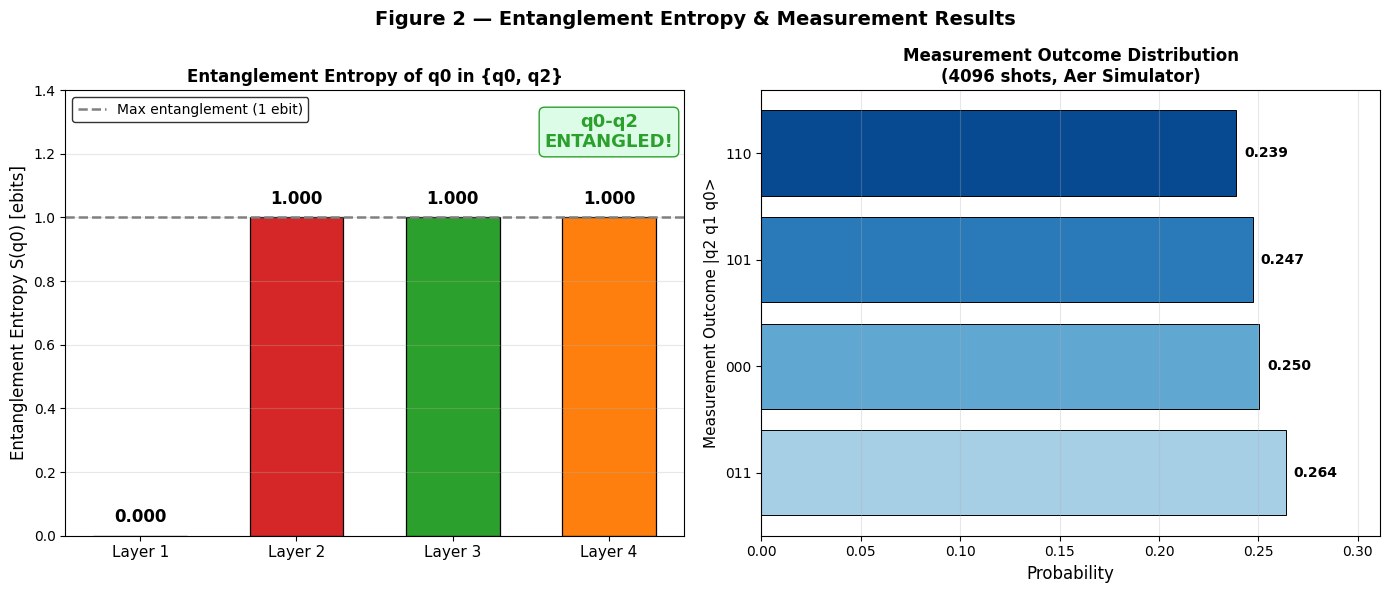

In [28]:
rc_white()
fig2, (ax_ee, ax_hist) = plt.subplots(1, 2, figsize=(14, 6), facecolor="white")
fig2.suptitle("Figure 2 — Entanglement Entropy & Measurement Results", fontsize=14, fontweight="bold")

# Entropy
bars = ax_ee.bar(range(1,5), entanglement_entropy_q02,
                 color=COLORS4, edgecolor="black", linewidth=0.9, width=0.6)
ax_ee.axhline(1.0, color="gray", linestyle="--", linewidth=1.8, label="Max entanglement (1 ebit)")
for bar, val in zip(bars, entanglement_entropy_q02):
    ax_ee.text(bar.get_x()+bar.get_width()/2, val+0.03, f"{val:.3f}",
               ha="center", va="bottom", fontsize=12, fontweight="bold")
ax_ee.set_xticks(range(1,5))
ax_ee.set_xticklabels([f"Layer {i}" for i in range(1,5)], fontsize=11)
ax_ee.set_ylim(0, 1.4)
ax_ee.set_ylabel("Entanglement Entropy S(q0) [ebits]", fontsize=12)
ax_ee.set_title("Entanglement Entropy of q0 in {q0, q2}", fontsize=12, fontweight="bold")
ax_ee.legend(fontsize=10)
ax_ee.text(4, 1.22, "q0-q2\nENTANGLED!", ha="center", color="#2ca02c",
           fontsize=13, fontweight="bold",
           bbox=dict(facecolor="#dcfce7", edgecolor="#2ca02c", boxstyle="round,pad=0.3"))
ax_ee.grid(axis="y", alpha=0.3)

# Histogram
sc = sorted(counts.items(), key=lambda x: -x[1])[:8]
sh = [s for s,_ in sc]
fq = [c/4096 for _,c in sc]
bc = plt.cm.Blues(np.linspace(0.35, 0.9, len(sh)))
hbars = ax_hist.barh(sh, fq, color=bc, edgecolor="black", linewidth=0.7)
for i, (s, f) in enumerate(zip(sh, fq)):
    ax_hist.text(f+0.004, i, f"{f:.3f}", va="center", fontsize=10, fontweight="bold")
ax_hist.set_xlabel("Probability", fontsize=12)
ax_hist.set_ylabel("Measurement Outcome |q2 q1 q0>", fontsize=11)
ax_hist.set_title("Measurement Outcome Distribution\n(4096 shots, Aer Simulator)", fontsize=12, fontweight="bold")
ax_hist.set_xlim(0, max(fq)*1.18)
ax_hist.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## FIGURE 3 — Statevector Probabilities (all 4 layers)

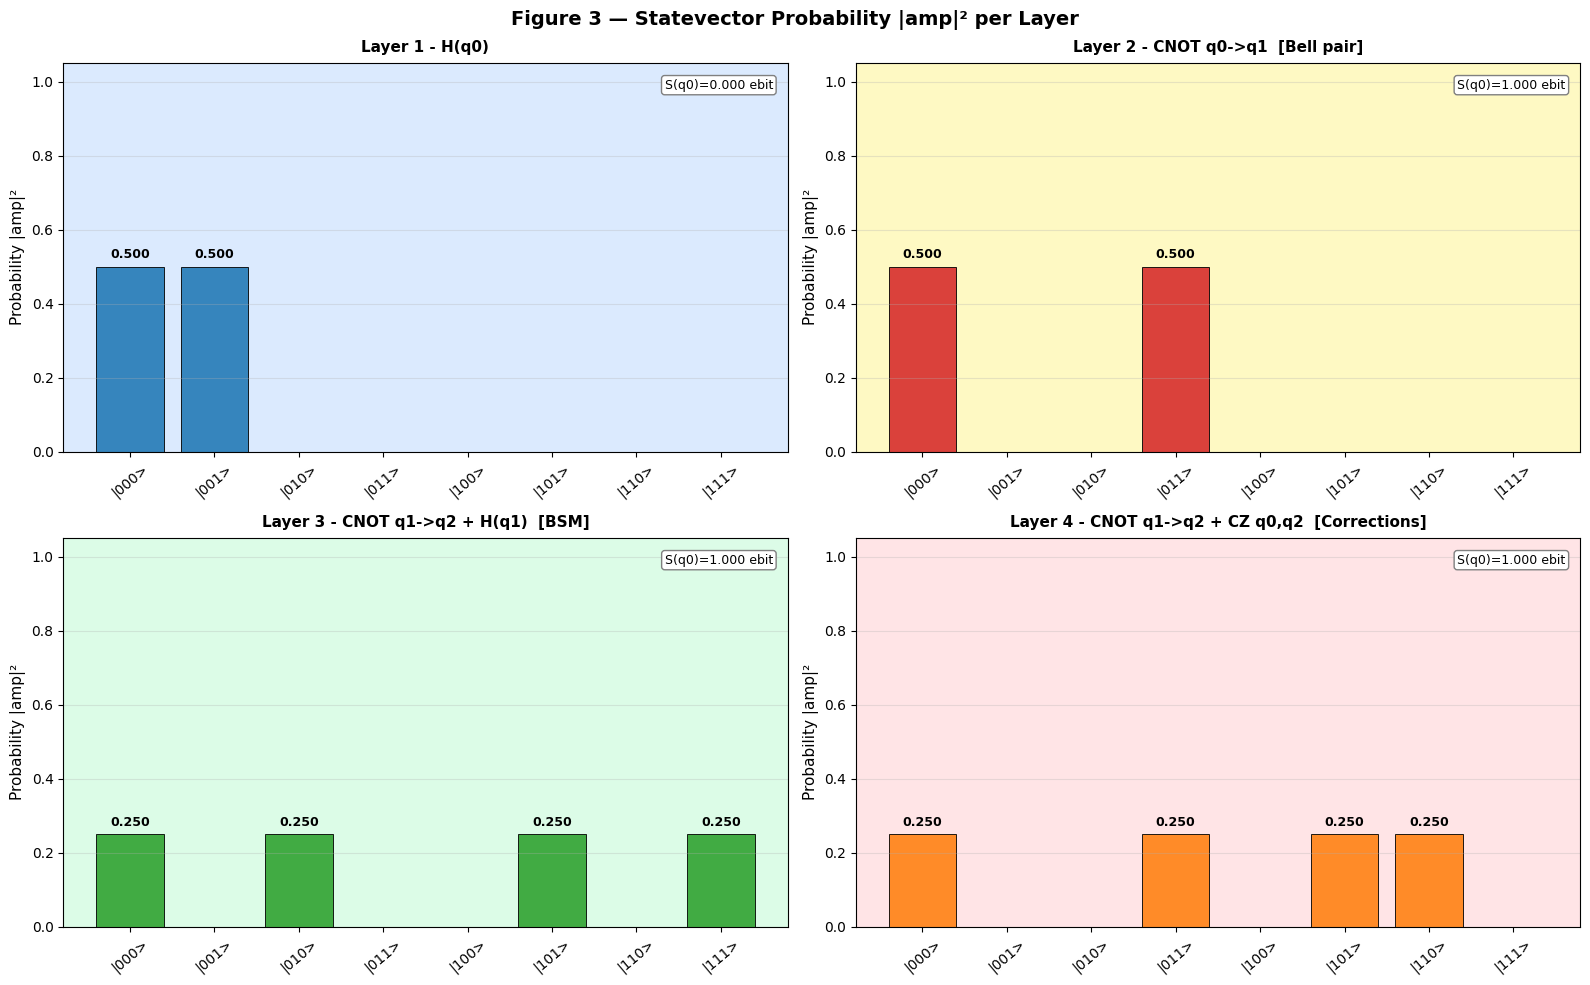

In [29]:
rc_white()
fig3, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="white")
fig3.suptitle("Figure 3 — Statevector Probability |amp|² per Layer", fontsize=14, fontweight="bold")
axes = axes.flatten()
basis = [f"|{i:03b}>" for i in range(8)]

for li in range(4):
    ax = axes[li]
    ax.set_facecolor(LAYER_BG[li])
    sv = statevectors[li]
    probs = np.abs(sv.data)**2
    b = ax.bar(basis, probs, color=COLORS4[li], edgecolor="black", linewidth=0.7, alpha=0.88)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability |amp|²", fontsize=11)
    ax.set_title(f"{LAYER_LABELS[li]}", fontsize=11, fontweight="bold", pad=8)
    ax.tick_params(axis="x", rotation=40, labelsize=10)
    ax.grid(axis="y", alpha=0.3)
    for bar, p in zip(b, probs):
        if p > 0.02:
            ax.text(bar.get_x()+bar.get_width()/2, p+0.015, f"{p:.3f}",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")
    ee_val = entanglement_entropy_q02[li]
    ax.text(0.98, 0.96, f"S(q0)={ee_val:.3f} ebit",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.25"))

plt.tight_layout()
plt.show()

## FIGURES 4a/4b/4c — Bloch Spheres, ONE figure per qubit (4 layers each)

### Bloch sphere

In [30]:
def draw_bloch_sphere(ax, bx, by, bz, qubit, layer_idx):
    """Draw a single Bloch sphere with state vector and spherical coord labels."""
    # Wireframe sphere
    u = np.linspace(0, 2*np.pi, 40)
    v = np.linspace(0, np.pi, 25)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="#cccccc", alpha=0.25, linewidth=0.5)

    # Axis lines
    for s, e in [([0,0,-1.35],[0,0,1.35]),
                 ([-1.35,0,0],[1.35,0,0]),
                 ([0,-1.35,0],[0,1.35,0])]:
        ax.plot([s[0],e[0]], [s[1],e[1]], [s[2],e[2]], color="#888888", lw=1.0, alpha=0.7)

    # Equator circle
    eq = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(eq), np.sin(eq), np.zeros(100), color="#aaaaaa", lw=0.9, ls="--", alpha=0.6)

    # Axis labels
    ax.text(0,  0,  1.65, "|0>", ha="center", va="center", fontsize=10, color="black", fontweight="bold")
    ax.text(0,  0, -1.65, "|1>", ha="center", va="center", fontsize=10, color="black", fontweight="bold")
    ax.text(1.75, 0,  0,  "X",   ha="center", va="center", fontsize=10, color="#555555")
    ax.text(0,  1.75, 0,  "Y",   ha="center", va="center", fontsize=10, color="#555555")

    r   = np.sqrt(bx**2 + by**2 + bz**2)
    col = QUBIT_COLORS[qubit]

    if r > 1e-3:
        # Bloch vector arrow
        ax.quiver(0, 0, 0, bx, by, bz, color=col, lw=3.0,
                  arrow_length_ratio=0.15, normalize=False)
        ax.scatter([bx], [by], [bz], color=col, s=80, zorder=6)
        # Dashed projection lines to help read 3D coords
        ax.plot([bx, bx], [by, by], [0,  bz], color=col, lw=1.0, ls=":", alpha=0.55)
        ax.plot([bx, bx], [0,  by], [0,  0],  color=col, lw=1.0, ls=":", alpha=0.55)
        ax.plot([0,  bx], [0,  0],  [0,  0],  color=col, lw=1.0, ls=":", alpha=0.55)
    else:
        # Mixed / maximally entangled — star at center
        ax.scatter([0], [0], [0], color=col, s=300, marker="*", zorder=6)

    # Spherical coordinate labels below sphere
    th = np.degrees(np.arccos(np.clip(bz/r, -1, 1))) if r > 1e-3 else 0.0
    ph = np.degrees(np.arctan2(by, bx))
    label = (f"|r| = {r:.4f}\n"
             f"theta = {th:.2f} deg\n"
             f"phi   = {ph:.2f} deg\n"
             f"x={bx:+.3f}  y={by:+.3f}  z={bz:+.3f}")
    ax.text2D(0.50, -0.12, label, transform=ax.transAxes,
              ha="center", va="top", fontsize=9, color=col, fontweight="bold",
              family="monospace",
              bbox=dict(facecolor="white", edgecolor=col,
                        boxstyle="round,pad=0.35", alpha=0.90))

    ax.set_xlim([-1.6, 1.6]); ax.set_ylim([-1.6, 1.6]); ax.set_zlim([-1.6, 1.6])
    ax.set_box_aspect([1, 1, 1])
    ax.set_facecolor(LAYER_BG[layer_idx])
    ax.axis("off")
    ax.view_init(elev=22, azim=40)

In [31]:
QUBIT_NAMES = ["q0  (Alice)", "q1  (Middle / BSM)", "q2  (Bob)"]
QUBIT_NOTES = [
    "q0: starts entangled with q1, ends entangled with q2",
    "q1: mediator — Bell State Measurement (BSM) performed here",
    "q2: never touched q0 directly, yet becomes entangled with q0 after Layer 4",
]

C:\Users\Garn\AppData\Local\Temp\ipykernel_28716\2738514559.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.92])


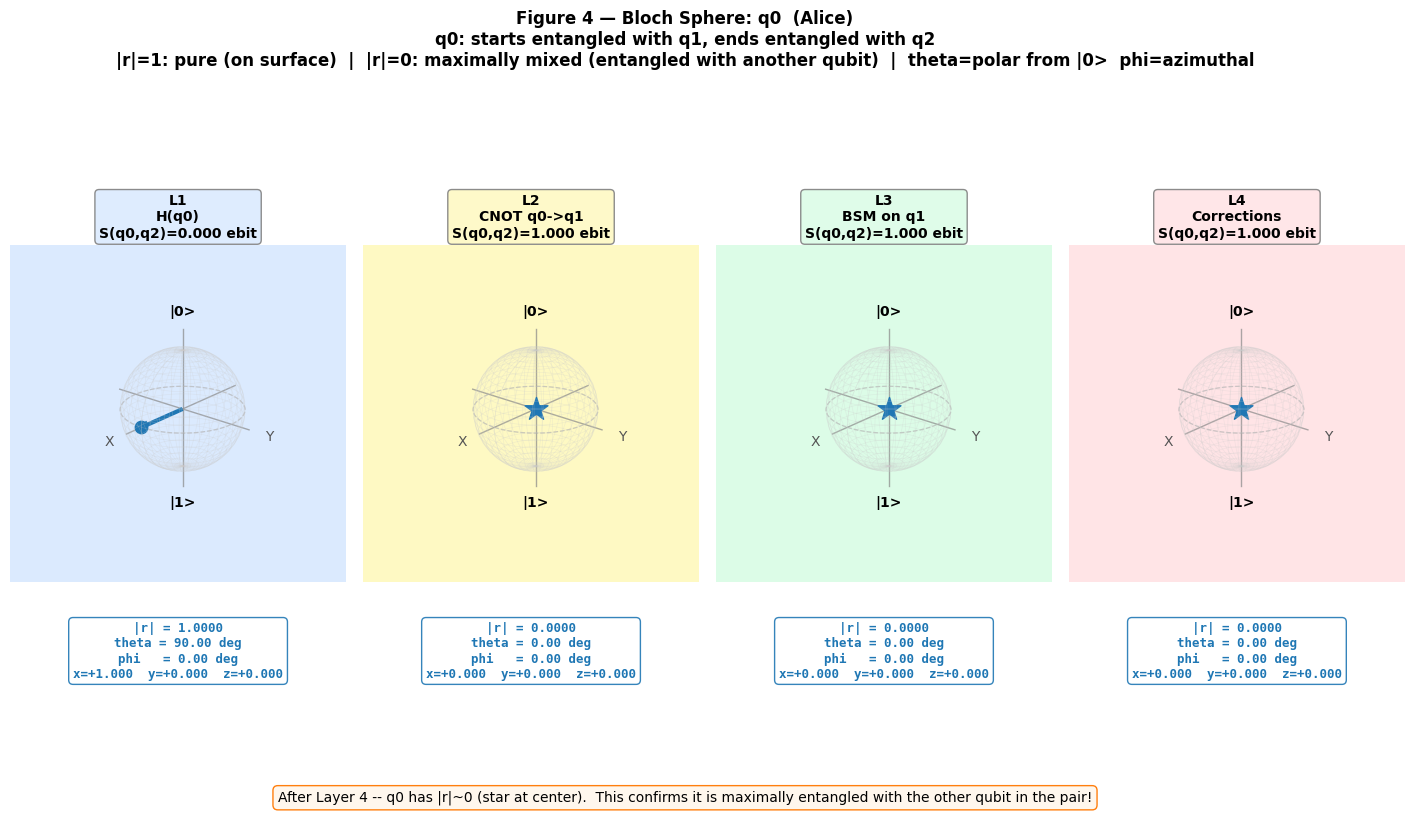

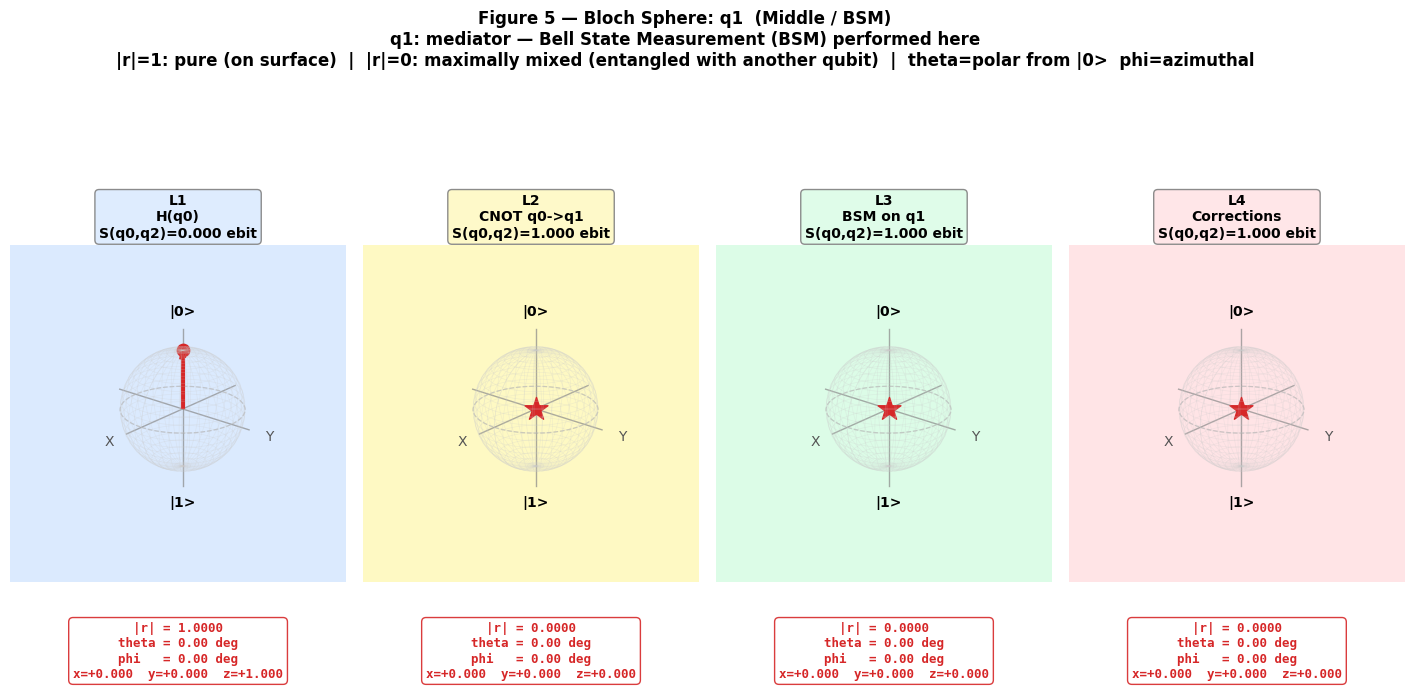

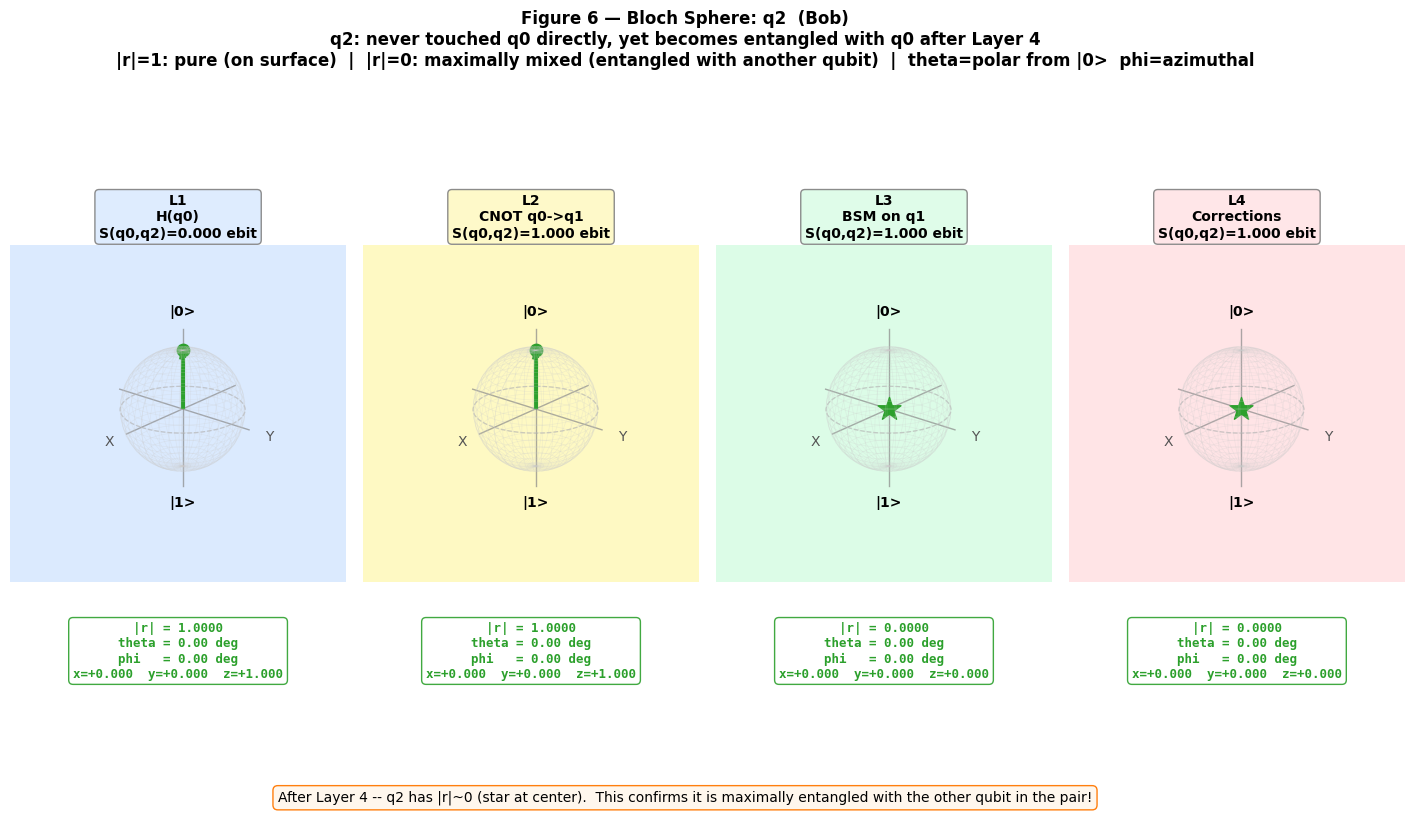

In [32]:
for q in range(3):
    rc_white()
    fig_q = plt.figure(figsize=(18, 8), facecolor="white")
    fig_q.suptitle(
        f"Figure {4+q} — Bloch Sphere: {QUBIT_NAMES[q]}\n"
        f"{QUBIT_NOTES[q]}\n"
        "|r|=1: pure (on surface)  |  |r|=0: maximally mixed (entangled with another qubit)  |  "
        "theta=polar from |0>  phi=azimuthal",
        fontsize=12, fontweight="bold", y=1.00
    )

    gs_q = gridspec.GridSpec(1, 4, figure=fig_q, wspace=0.05)

    for li in range(4):
        ax3d = fig_q.add_subplot(gs_q[0, li], projection="3d")
        bx, by, bz = bloch_data[(li, q)]
        draw_bloch_sphere(ax3d, bx, by, bz, q, li)

        # Layer title above each sphere
        ee_val = entanglement_entropy_q02[li]
        ax3d.set_title(
            f"{LAYER_SHORT[li]}\nS(q0,q2)={ee_val:.3f} ebit",
            fontsize=10, fontweight="bold", color="black", pad=6,
            bbox=dict(facecolor=LAYER_BG[li], edgecolor="gray",
                      boxstyle="round,pad=0.3", alpha=0.9)
        )

    # Highlight if this is q0 or q2 (the entangled pair)
    if q in [0, 2]:
        fig_q.text(0.50, 0.01,
            f"After Layer 4 -- q{q} has |r|~0 (star at center).  "
            "This confirms it is maximally entangled with the other qubit in the pair!",
            ha="center", fontsize=10, color="black",
            bbox=dict(facecolor="#fff7ed", edgecolor="#ff7f0e",
                      boxstyle="round,pad=0.35"))

    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()